In [1]:
from pathlib import Path
import gmsh

# Optional preprocessing: define geometry once, optionally save as .geo
DATA_DIR = Path.cwd().resolve().parents[0] / "io" / "dataset" / "deep_notched"
DATA_DIR.mkdir(parents=True, exist_ok=True)
GEO_PATH = DATA_DIR / "deep_notched.geo"

def build_deep_notched_geometry(geo, lc=100.0):
    geo.addPoint(0.0,   0.0,   0.0, lc, 1)
    geo.addPoint(100.0, 0.0,   0.0, lc, 2)
    geo.addPoint(100.0, 100.0, 0.0, lc, 3)
    geo.addPoint(0.0,   100.0, 0.0, lc, 4)
    geo.addPoint(0.0,   25.0,  0.0, lc, 5)
    geo.addPoint(0.0,   75.0,  0.0, lc, 6)
    geo.addPoint(0.0,   50.0,  0.0, lc, 7)
    geo.addPoint(100.0, 50.0,  0.0, lc, 8)
    geo.addPoint(100.0, 75.0,  0.0, lc, 9)
    geo.addPoint(100.0, 25.0,  0.0, lc, 10)

    geo.addCircleArc(5, 7, 6, 1)
    geo.addCircleArc(9, 8, 10, 2)
    geo.addLine(3, 4, 3)
    geo.addLine(4, 6, 4)
    geo.addLine(5, 1, 5)
    geo.addLine(1, 2, 6)
    geo.addLine(2, 10, 7)
    geo.addLine(9, 3, 8)
    geo.addCurveLoop([3, 4, -1, 5, 6, 7, -2, 8], 1)
    geo.addPlaneSurface([1], 1)

SAVE_GEO = True

if SAVE_GEO:
    try:
        gmsh.initialize()
        gmsh.option.setNumber("General.Terminal", 1)
        gmsh.model.add("deep_notched_geo")
        build_deep_notched_geometry(gmsh.model.geo, lc=100.0)
        gmsh.model.geo.synchronize()

        try:
            gmsh.write(str(GEO_PATH))
        except Exception:
            geo_unrolled = GEO_PATH.with_suffix(".geo_unrolled")
            gmsh.write(str(geo_unrolled))
            GEO_PATH.write_text(geo_unrolled.read_text(encoding="utf-8"), encoding="utf-8")
    finally:
        gmsh.finalize()

    print(f"Saved geometry file: {GEO_PATH}")
else:
    print("Geometry function defined. Set SAVE_GEO = True to export .geo")

Info    : Writing '/home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.geo'...
Info    : Writing '/home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.geo_unrolled'...
Info    : Done writing '/home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.geo_unrolled'
Saved geometry file: /home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.geo


Error   : Unknown output file format


In [ ]:
import gmsh
import meshio
import numpy as np

# Optional preprocessing: generate mesh from previously defined geometry function
# Run Cell 1 first so build_deep_notched_geometry is available.
if "build_deep_notched_geometry" not in globals():
    raise RuntimeError("Run Cell 1 first to define build_deep_notched_geometry().")

# Tune this for spatial resolution near the notch (smaller -> finer notch mesh)
notch_refinement = 0.3
# Global and local mesh controls
base_lc = 2.0
dist_min = .05
dist_max = 5.0

MSH_PATH = DATA_DIR / "deep_notched.msh"
XDMF_PATH = DATA_DIR / "deep_notched.xdmf"

try:
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 1)
    gmsh.model.add("deep_notched_mesh")

    build_deep_notched_geometry(gmsh.model.geo, lc=base_lc)
    gmsh.model.geo.synchronize()

    # Let Gmsh auto-size from geometry while refining near notch arcs
    gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 1)
    gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 1)
    gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 1)

    dist_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(dist_field, "CurvesList", [1, 2])
    gmsh.model.mesh.field.setNumber(dist_field, "Sampling", 200)

    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "InField", dist_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "LcMin", base_lc * notch_refinement)
    gmsh.model.mesh.field.setNumber(threshold_field, "LcMax", base_lc)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", dist_min)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", dist_max)

    min_field = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", [threshold_field])
    gmsh.model.mesh.field.setAsBackgroundMesh(min_field)

    gmsh.model.mesh.generate(2)
    gmsh.write(str(MSH_PATH))

finally:
    gmsh.finalize()

msh = meshio.read(str(MSH_PATH))
triangle_cells = np.vstack([c.data for c in msh.cells if c.type == "triangle"])
triangle_mesh = meshio.Mesh(
    points=msh.points[:, :2],
    cells=[("triangle", triangle_cells)],
)
meshio.write(str(XDMF_PATH), triangle_mesh, file_format="xdmf")

print(f"Saved mesh: {MSH_PATH}")
print(f"Saved mesh for FEniCS: {XDMF_PATH}")
print(f"Notch refinement factor (LcMin/base_lc): {notch_refinement}")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [ 20%] Meshing curve 2 (Circle)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Line)
Info    : Done meshing 1D (Wall 0.0633591s, CPU 0.066915s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.207283s, CPU 0.215234s)
Info    : 8799 nodes 17602 elements
Info    : Writing '/home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.msh'...
Info    : Done writing '/home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.msh'

Saved mesh: /home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.msh
Saved mesh for FEniCS: /home/r2d2/code/PhD/src/phd/io/dataset/deep_notched/deep_notched.xdmf
Notch refinement factor (LcMin/base_lc): 0.3


In [10]:
from pathlib import Path

from fenics import *
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path.cwd().resolve().parents[0] / "io" / "dataset" / "deep_notched"

# import meshio #--> convert to xdmf if not done already
# msh = meshio.read(str(DATA_DIR / "deep_notched.msh"))
# for cell in msh.cells:
#     triangle_cells = cell.data

# triangle_mesh = meshio.Mesh(points=msh.points[:, :2], cells={"triangle": triangle_cells})
# meshio.write(str(DATA_DIR / "deep_notched.xdmf"), triangle_mesh, file_format="xdmf")

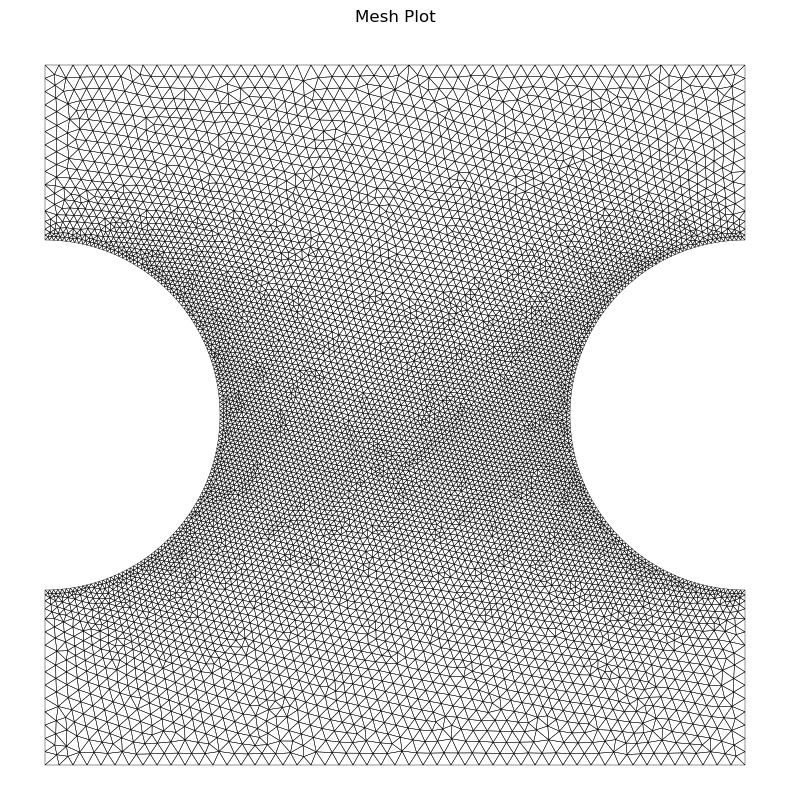

Mesh dimension: 2


In [29]:
# Load the mesh
mesh = Mesh()
with XDMFFile(str(DATA_DIR / "deep_notched.xdmf")) as infile:
    infile.read(mesh)

plot_mesh = True  # Set to True if you want to plot the mesh
if plot_mesh:
    # Extract vertices and cells from the mesh
    vertices = mesh.coordinates()
    cells = mesh.cells()

    # Plot the mesh
    plt.figure(figsize=(10, 10))
    for cell in cells:
        vertices_cell = vertices[cell]
        plt.fill(vertices_cell[:, 0], vertices_cell[:, 1], edgecolor='k', linewidth=0.3, fill=False)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Mesh Plot')
    plt.gca().set_aspect('equal')
    plt.axis('off')
    plt.show()

    print("Mesh dimension:", mesh.geometric_dimension())

In [15]:
stress_bc = False
material_type = 'isotropic'  # 'isotropic' or 'orthotropic'

# Define geometry parameters
Lmax = 100.0
Hmax = 100.0

pstress = 50.0

# Material parameters (converted to N/mm^2)
if material_type == 'isotropic':
    E   = 52e3      # GPa->N/mm^2
    nu  = 0.3
    # isotropic plane stress stiffness factors
    def sigma_tensor(u):
        eps = sym(nabla_grad(u))
        return as_tensor([
            [E/(1-nu**2)*(eps[0,0] + nu*eps[1,1]), E/(1+nu)*eps[0,1]],
            [E/(1+nu)*eps[1,0],             E/(1-nu**2)*(eps[1,1] + nu*eps[0,0])]
        ])

elif material_type == 'orthotropic':
    Q11, Q22, Q12, Q66 = 41e3, 10.3e3, 3.1e3, 4e3
    theta = 45.0 # degrees
    theta_rad = theta * np.pi / 180.0  # Convert to radians
    # orthotropic plane stress
    def sigma_tensor(u):
        eps = sym(nabla_grad(u))

        # Rotation matrix
        c = cos(theta_rad)
        s = sin(theta_rad)
        R = as_tensor([[c, -s],
                       [s,  c]])
        RT = R.T

        # Transform strain to material coordinates
        eps_local = RT * eps * R

        # Stress in material coordinates
        sigma_local = as_tensor([
            [Q11*eps_local[0,0] + Q12*eps_local[1,1], 2*Q66*eps_local[0,1]],
            [2*Q66*eps_local[1,0], Q12*eps_local[0,0] + Q22*eps_local[1,1]]
        ])

        # Transform stress back to global coordinates
        sigma_global = R * sigma_local * RT
        return sigma_global


# Define boundary condition
V = VectorFunctionSpace(mesh, 'P', 1)

tol = 1E-14

def top_boundary(x, on_boundary):
    return on_boundary and near(x[1], Hmax, tol)

def bottom_boundary(x, on_boundary):
    return on_boundary and near(x[1], 0, tol)


bc1 = DirichletBC(V.sub(0), Constant(0), bottom_boundary)
bc2 = DirichletBC(V.sub(1), Constant(0), bottom_boundary)
bc3 = DirichletBC(V.sub(0), Constant(0), top_boundary)
uy_top = pstress * Hmax / E  if material_type == 'isotropic' else pstress* Hmax / Q22
# uy_top = 1 # 1 mm
bc4 = DirichletBC(V.sub(1), Constant(uy_top), top_boundary)     # uy on top
bc = [bc1, bc2] if stress_bc else [bc1, bc2, bc3, bc4]

#mark top boundary
if stress_bc:
    top = AutoSubDomain(top_boundary)
    boundaries = MeshFunction("size_t", mesh, mesh.topology().dim() - 1)
    boundaries.set_all(0)
    top.mark(boundaries, 1)
    ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# Define strain and stress

def epsilon(u):
    return 0.5*(nabla_grad(u) + nabla_grad(u).T)
    # return sym(nabla_grad(u))

# Define variational problem
x = SpatialCoordinate(mesh)
u = TrialFunction(V)
d = u.geometric_dimension()  # space dimension
v = TestFunction(V)
f = Constant((0, 0))

T = Constant((0, pstress))
a = inner(sigma_tensor(u), epsilon(v))*dx

if stress_bc:
    L = dot(f, v)*dx + dot(T, v)*ds(1)
else:
    L = dot(Constant((0.0, 0.0)), v) * dx # No external forces

# Compute solution
u = Function(V)
solve(a == L, u, bc)

tensor_space = TensorFunctionSpace(mesh, 'P', 1)
strain = project(epsilon(u), tensor_space)
stress = project(sigma_tensor(u), tensor_space)
print(f"Uy top: {uy_top:.3e} mm")

Solving linear variational problem.
Uy top: 9.615e-02 mm


Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.
Object cannot be plotted directly, projecting to piecewise linears.


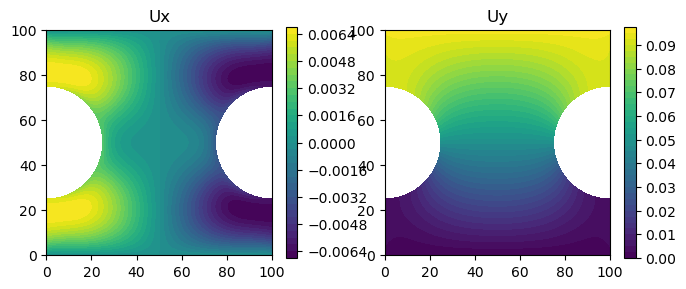

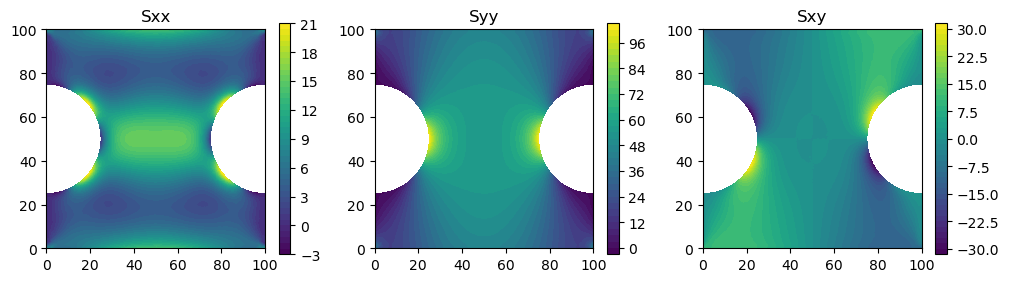

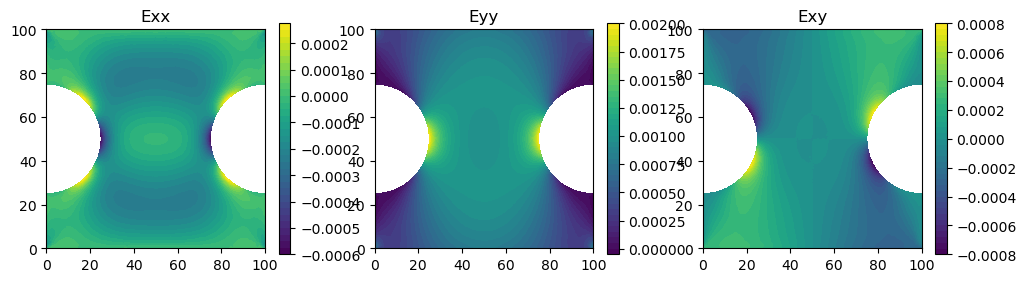

In [16]:
plt.subplots(1,2, figsize=(8, 3))

plt.subplot(121)
im = plot(u[0], mesh=mesh, title='Ux')
plt.colorbar(im)
plt.subplot(122)
im = plot(u[1], title='Uy')
plt.colorbar(im)

plt.subplots(1,3, figsize=(12, 3))
plt.subplot(131)
im = plot(stress[0, 0], title='Sxx')
plt.colorbar(im)
plt.subplot(132)
im = plot(stress[1, 1], title='Syy')
plt.colorbar(im)
plt.subplot(133)
im = plot(stress[0, 1], title='Sxy')
plt.colorbar(im)

plt.subplots(1,3, figsize=(12, 3))
plt.subplot(131)
im = plot(strain[0, 0], title='Exx')
plt.colorbar(im)
plt.subplot(132)
im = plot(strain[1, 1], title='Eyy')
plt.colorbar(im)
plt.subplot(133)
im = plot(strain[0, 1], title='Exy')
plt.colorbar(im)

/tmp/ipykernel_1578259/1977090168.py:33: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  im = AX.pcolor(X, Y, C, cmap=colormap, shading='auto')


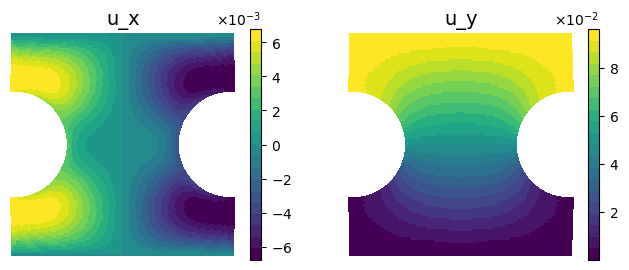

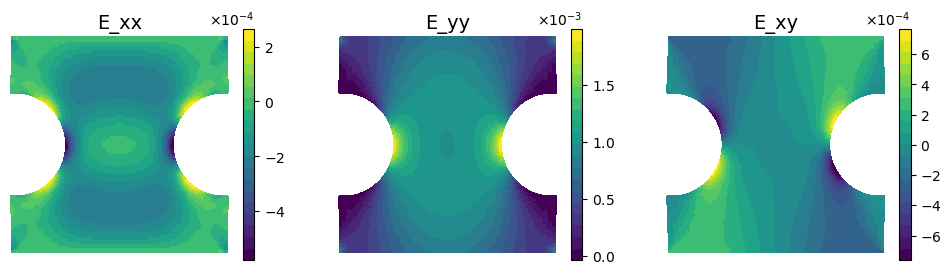

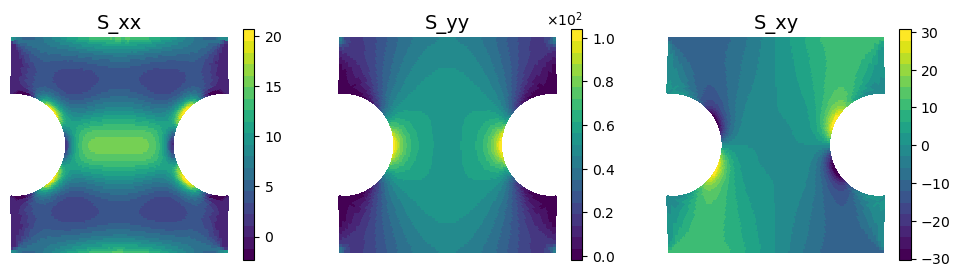

In [28]:
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# Load geometry mapping
from scipy.ndimage import map_coordinates
nx = 100
ny = 100
material_type = 'isotropic'  # 'isotropic' or 'orthotropic'

Xp = np.loadtxt(DATA_DIR / f"{material_type}_{nx}x{ny}.dat")

# Interpolate mapping
X_map_points = Xp[:, 0].reshape((ny, nx)).T
Y_map_points = Xp[:, 1].reshape((ny, nx)).T

def geometry_mapping(x, y, padding=1e-6):
    x_pos = x / x_max * (nx - 1) * (1 - 2 * padding) + padding
    y_pos = y / y_max * (ny - 1) * (1 - 2 * padding) + padding

    x_mapped = map_coordinates(X_map_points, [x_pos, y_pos], order=1)
    y_mapped = map_coordinates(Y_map_points, [x_pos, y_pos], order=1)

    return x_mapped, y_mapped


def pcolor_plot(AX, X, Y, C, title, colormap="copper", set_axis='off', colorbar=True, **kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap, shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax, shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis(set_axis)
    AX.set_title(title, fontsize=14)
    fig.colorbar(im, ax=AX, format=formatter)
    return im

cmap = plt.get_cmap('viridis')
num_colors = 20
color_values = [cmap(i) for i in np.linspace(0, 1, num_colors)]
cmap = ListedColormap(color_values)

n_mesh_x = 100
n_mesh_y = 100

x_plot = np.linspace(0, Lmax, n_mesh_x)
y_plot = np.linspace(0, Hmax, n_mesh_y)
X, Y = np.meshgrid(x_plot, y_plot)

X, Y = geometry_mapping(X, Y)

X_grid = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))

u.set_allow_extrapolation(True)
strain.set_allow_extrapolation(True)
stress.set_allow_extrapolation(True)

# Evaluate the solution on the grid
u_val = np.array([u(X_grid[i, :]) for i in range(X_grid.shape[0])])
strain_val = np.array([strain(X_grid[i, :]) for i in range(X_grid.shape[0])])
strain_val = np.array([strain_val[:, 0], strain_val[:, 3], 0.5 * (strain_val[:, 1] + strain_val[:, 2])]).T
stress_val = np.array([stress(X_grid[i, :]) for i in range(X_grid.shape[0])])
stress_val = np.array([stress_val[:, 0], stress_val[:, 3], 0.5 * (stress_val[:, 1] + stress_val[:, 2])]).T

# # Plot displacement
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
im = pcolor_plot(ax[0], X, Y, u_val[:, 0].reshape(X.shape), "u_x", colormap=cmap)
im = pcolor_plot(ax[1], X, Y, u_val[:, 1].reshape(X.shape), "u_y", colormap=cmap)

# # Plot strain
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
im = pcolor_plot(ax[0], X, Y, strain_val[:, 0].reshape(X.shape), "E_xx", colormap=cmap)
im = pcolor_plot(ax[1], X, Y, strain_val[:, 1].reshape(X.shape), "E_yy", colormap=cmap)
im = pcolor_plot(ax[2], X, Y, strain_val[:, 2].reshape(X.shape), "E_xy", colormap=cmap)

# Plot stress
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
im = pcolor_plot(ax[0], X, Y, stress_val[:, 0].reshape(X.shape), "S_xx", colormap=cmap)
im = pcolor_plot(ax[1], X, Y, stress_val[:, 1].reshape(X.shape), "S_yy", colormap=cmap)
im = pcolor_plot(ax[2], X, Y, stress_val[:, 2].reshape(X.shape), "S_xy", colormap=cmap)

plt.show()

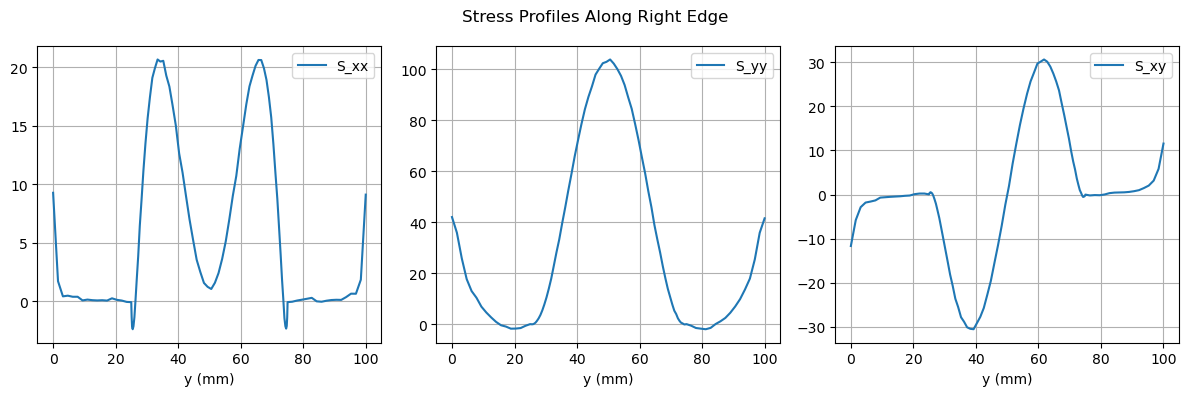

In [24]:
# Right-edge stress profiles (curvilinear edge from mapped grid)
if "Y" not in globals() or "stress_val" not in globals():
    raise RuntimeError("Run Cell 8 first to compute mapped grid and stress values.")

# Final column corresponds to the right edge in the mapped plotting grid
y_right = Y[:, -1]
sxx_right = stress_val[:, 0].reshape(X.shape)[:, -1]
syy_right = stress_val[:, 1].reshape(X.shape)[:, -1]
sxy_right = stress_val[:, 2].reshape(X.shape)[:, -1]

# Ensure a clean bottom-to-top profile
order = np.argsort(y_right)
y_right = y_right[order]
sxx_right = sxx_right[order]
syy_right = syy_right[order]
sxy_right = sxy_right[order]

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(y_right, sxx_right, label='S_xx')
axs[1].plot(y_right, syy_right, label='S_yy')
axs[2].plot(y_right, sxy_right, label='S_xy')
for ax in axs:
    ax.set_xlabel('y (mm)')
    ax.legend()
    ax.grid()
plt.suptitle('Stress Profiles Along Right Edge')
plt.tight_layout()

In [ ]:
# Quick traction check on right curvilinear edge: t = sigma . n
if "X" not in globals() or "Y" not in globals() or "stress_val" not in globals():
    raise RuntimeError("Run Cell 8 first to compute X, Y and stress_val.")

# Right edge from mapped grid (final column)
x_right = X[:, -1]
y_right = Y[:, -1]
sxx_right = stress_val[:, 0].reshape(X.shape)[:, -1]
syy_right = stress_val[:, 1].reshape(X.shape)[:, -1]
sxy_right = stress_val[:, 2].reshape(X.shape)[:, -1]

# Tangent from geometric curve derivative
dx_ds = np.gradient(x_right)
dy_ds = np.gradient(y_right)
t_norm = np.sqrt(dx_ds**2 + dy_ds**2) + 1e-14
tx_hat = dx_ds / t_norm
ty_hat = dy_ds / t_norm

# One normal (sign is arbitrary for traction-free check)
nx = ty_hat
ny = -tx_hat

# Traction components in Cartesian basis
t_x = sxx_right * nx + sxy_right * ny
t_y = sxy_right * nx + syy_right * ny

# Normal/tangential traction scalars
t_n = t_x * nx + t_y * ny
t_t = t_x * (-ny) + t_y * nx

# Sort by altitude for readable plots
order = np.argsort(y_right)
y_plot = y_right[order]
t_x_plot = t_x[order]
t_y_plot = t_y[order]
t_n_plot = t_n[order]
t_t_plot = t_t[order]

# Report values nearest y=50
i50 = np.argmin(np.abs(y_plot - 50.0))
print(f"Nearest y to 50: {y_plot[i50]:.6f}")
print(f"t_x(y~50) = {t_x_plot[i50]:.6e}")
print(f"t_y(y~50) = {t_y_plot[i50]:.6e}")
print(f"t_n(y~50) = {t_n_plot[i50]:.6e}")
print(f"t_t(y~50) = {t_t_plot[i50]:.6e}")

# Plot traction along right edge
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(y_plot, t_x_plot, label="t_x")
ax[0].plot(y_plot, t_y_plot, label="t_y")
ax[0].set_xlabel("Altitude y on specimen")
ax[0].set_ylabel("Traction components")
ax[0].set_title("Right-edge traction (Cartesian)")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(y_plot, t_n_plot, label="t_n")
ax[1].plot(y_plot, t_t_plot, label="t_t")
ax[1].set_xlabel("Altitude y on specimen")
ax[1].set_ylabel("Traction components")
ax[1].set_title("Right-edge traction (normal/tangential)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [6]:
print(f"Ux_mean = {np.mean(u_val[:,0]):2e} ; Uy_mean = {np.mean(u_val[:,1]):2e}")
print(f"Exx_mean = {np.mean(strain_val[:,0]):2e} ; Eyy_mean = {np.mean(strain_val[:,1]):2e} ; Exy_mean = {np.mean(strain_val[:,2]):2e}")
print(f"Sxx_mean = {np.mean(stress_val[:,0]):2e} ; Syy_mean = {np.mean(stress_val[:,1]):2e} ; Sxy_mean = {np.mean(stress_val[:,2]):2e}")

Ux_mean = -5.841617e-06 ; Uy_mean = 2.427160e-01
Exx_mean = -1.162832e-03 ; Eyy_mean = 4.472906e-03 ; Exy_mean = -3.185352e-04
Sxx_mean = 2.014985e+01 ; Syy_mean = 6.523575e+01 ; Sxy_mean = 1.822185e+01


In [ ]:
# Save solution
solution_name = f"{material_type}_{n_mesh_x}x{n_mesh_y}{'_S_bc' if stress_bc else ''}{f'_{theta}deg' if material_type == 'orthotropic' else ''}.dat"
np.savetxt(DATA_DIR / solution_name, np.hstack((X_grid, u_val, strain_val, stress_val)), delimiter=' ')

In [ ]:
from scipy.interpolate import RegularGridInterpolator

# Load solution
data = np.loadtxt(DATA_DIR / "isotropic_100x100.dat")
X_val = data[:, :2]
u_val = data[:, 2:4]
stress_val = data[:, 7:10]

solution_val = np.hstack((u_val, stress_val))

# Interpolate solution
x_grid = np.linspace(0, x_max, n_mesh_x)
y_grid = np.linspace(0, y_max, n_mesh_y)

interpolators = []
for i in range(solution_val.shape[1]):
    interp = RegularGridInterpolator((x_grid, y_grid), solution_val[:, i].reshape(n_mesh_y, n_mesh_x).T)
    interpolators.append(interp)

solution_fn = lambda x, y: np.array([interp((x, y)) for interp in interpolators]).T

/tmp/ipykernel_1744330/3348841157.py:34: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')


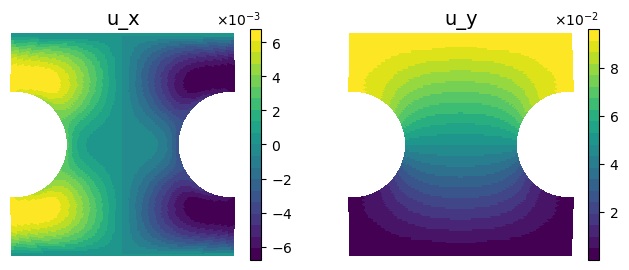

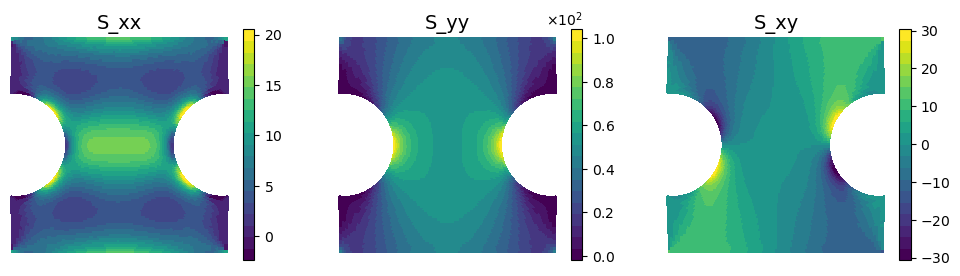

In [13]:
# Check interpolation
x_plot = np.linspace(0, Lmax, n_mesh_x)
y_plot = np.linspace(0, Hmax, n_mesh_y)
X, Y = np.meshgrid(x_plot, y_plot)
X_mapped, Y_mapped = geometry_mapping(X, Y)

X_grid = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))

solution_plot = solution_fn(X_grid[:, 0], X_grid[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
im = pcolor_plot(ax[0], X_mapped, Y_mapped, solution_plot[:,0].reshape(X.shape), "u_x",colormap=cmap)
im = pcolor_plot(ax[1], X_mapped, Y_mapped, solution_plot[:,1].reshape(X.shape), "u_y",colormap=cmap)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
im = pcolor_plot(ax[0], X_mapped, Y_mapped, solution_plot[:,2].reshape(X.shape), "S_xx",colormap=cmap)
im = pcolor_plot(ax[1], X_mapped, Y_mapped, solution_plot[:,3].reshape(X.shape), "S_yy",colormap=cmap)
im = pcolor_plot(ax[2], X_mapped, Y_mapped, solution_plot[:,4].reshape(X.shape), "S_xy",colormap=cmap)
